In [3]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [4]:
widthS = 10
widthF = 1
widthP = 30

X, Y = widthS+widthF+widthP, 200
lattice = Lattice(X, Y)

t = 1
T=0.01

muS = 3.5 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:] = muP

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthS:widthS + widthF] = h0

U = None

V0 = 4 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime0 = 2 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthS] = 0
V_prime[widthF+widthS] = V_prime0/2


In [5]:
H = Hamiltonian(t, mu, lattice,
                U=U, V=V, V_prime=V_prime,
                F_init=[0.3, 0.3, 0.3, 0.3],
                Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
                Fdd_init=[0.01, -0.01, 0.01j, -0.01j],
                hy=h)

In [6]:
bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=200, temperature=T)
F, Fuu, Fdd = H.get_correlations()
F0 = H.F0

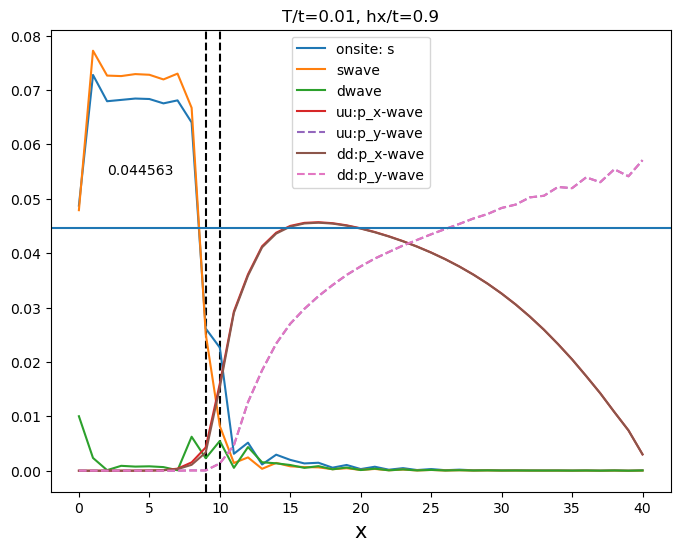

In [9]:
x = np.arange(0, widthS + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hx/t={h0}")
axs.axvline(int(widthS)-1, color='black', linestyle='--')
axs.axvline(widthS+widthF-1, color='black', linestyle='--')

axs.plot(x, np.abs(H.F0), label="onsite: s")
axs.plot(x, np.abs(F.swave), label="swave")
axs.plot(x, np.abs(F.dwave), label="dwave")

axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.plot(x, np.abs(Fdd.px), label="dd:p_x-wave")
axs.plot(x, np.abs(Fdd.py), "--", label="dd:p_y-wave")

# axs.plot(x, (np.abs(Fuu.px) + np.abs(Fdd.px))/2, label="uu-dd:p_x-wave")
# axs.plot(x, (np.abs(Fuu.py) + np.abs(Fdd.py))/2, "--", label="uu+dd:p_y-wave")

axs.set_xlabel("x", fontsize=15)
axs.axhline(np.abs(Fuu.px)[20])
axs.text(2, (np.abs(Fuu.px))[20]+0.01, f"{(np.abs(Fuu.px))[20]:.6f}")
axs.legend()
plt.show()